<a href="https://colab.research.google.com/github/sannithreddy04/codealpha_tasks/blob/main/Unemployment_in_India.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Dimensions: 740 rows, 9 columns
Time Range: May 2019 to Jun 2020

--- Impact Summary ---
              Estimated Unemployment Rate (%)  Estimated Employed  \
Period                                                              
During-Covid                        17.774363        6.517203e+06   
Pre-Covid                            9.509534        7.466028e+06   

              Estimated Labour Participation Rate (%)  
Period                                                 
During-Covid                                39.330049  
Pre-Covid                                   43.886119  


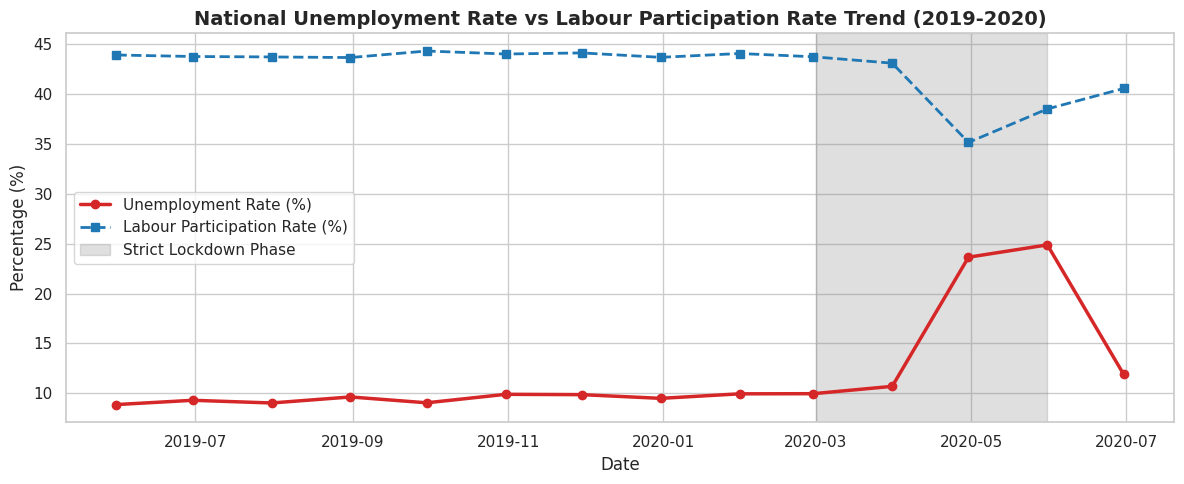

/tmp/ipykernel_926/597763427.py:60: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df, x='Date', y='Estimated Unemployment Rate (%)', hue='Area', ci=None, marker='o')


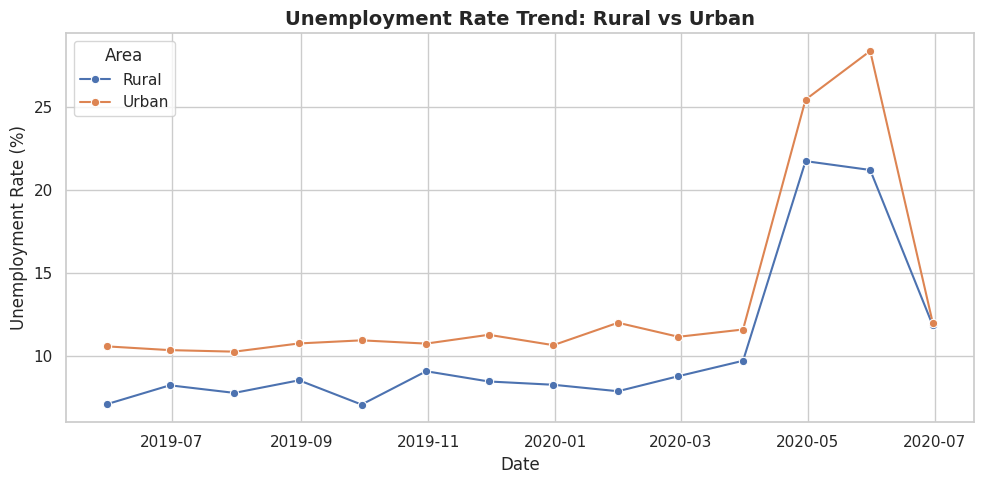

/tmp/ipykernel_926/597763427.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_states.values, y=top_states.index, palette='Reds_r')


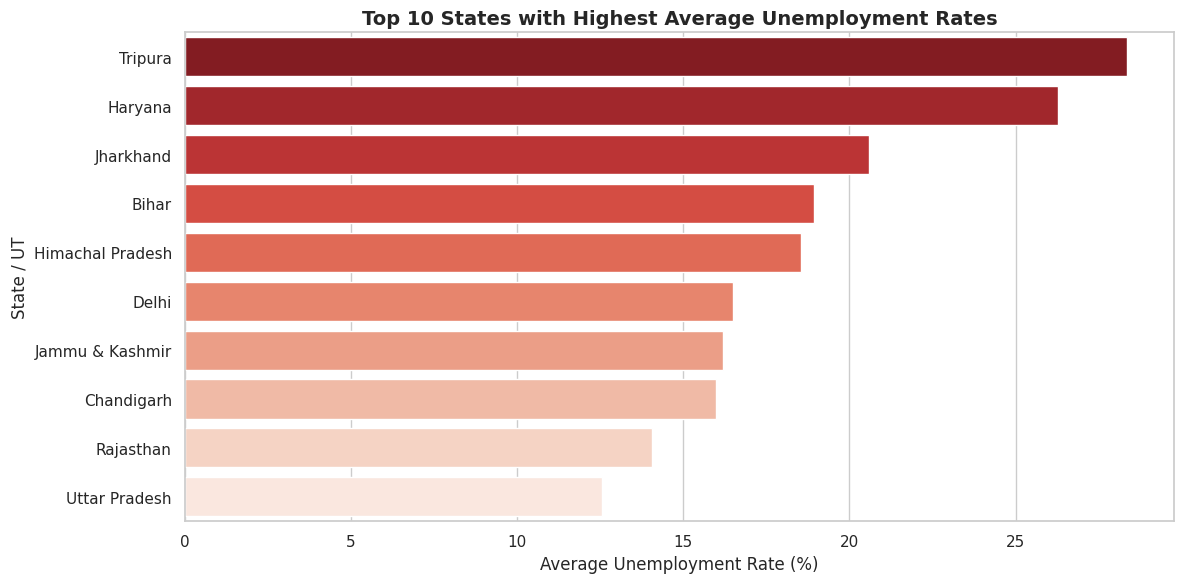

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# ----------------------------------------------------
# 1. DATA CLEANING & PREPROCESSING
# ----------------------------------------------------
# Load dataset and clean column whitespace
df = pd.read_csv('Unemployment in India.csv')
df.columns = df.columns.str.strip()

# Drop missing records (28 trailing null rows in dataset)
df.dropna(inplace=True)

# Parse dates and extract temporal features
df['Date'] = pd.to_datetime(df['Date'].str.strip(), format='%d-%m-%Y')
df['Month_Year'] = df['Date'].dt.to_period('M')
df['Period'] = np.where(df['Date'] < '2020-03-01', 'Pre-Covid', 'During-Covid')

print(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Time Range: {df['Date'].min().strftime('%b %Y')} to {df['Date'].max().strftime('%b %Y')}")

# ----------------------------------------------------
# 2. EXPLORATORY DATA ANALYSIS (EDA)
# ----------------------------------------------------
# Overall Pre-Covid vs During-Covid metrics
covid_impact = df.groupby('Period')[['Estimated Unemployment Rate (%)',
                                     'Estimated Employed',
                                     'Estimated Labour Participation Rate (%)']].mean()
print("\n--- Impact Summary ---")
print(covid_impact)

# ----------------------------------------------------
# 3. VISUALIZATIONS
# ----------------------------------------------------
# A. Monthly National Unemployment Trend & Covid Spike
monthly_trend = df.groupby('Date')[['Estimated Unemployment Rate (%)',
                                    'Estimated Labour Participation Rate (%)']].mean().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(monthly_trend['Date'], monthly_trend['Estimated Unemployment Rate (%)'],
         marker='o', color='#d62728', linewidth=2.5, label='Unemployment Rate (%)')
plt.plot(monthly_trend['Date'], monthly_trend['Estimated Labour Participation Rate (%)'],
         marker='s', color='#1f77b4', linewidth=2, linestyle='--', label='Labour Participation Rate (%)')
plt.axvspan(pd.to_datetime('2020-03-01'), pd.to_datetime('2020-05-31'), color='gray', alpha=0.25, label='Strict Lockdown Phase')
plt.title('National Unemployment Rate vs Labour Participation Rate Trend (2019-2020)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Percentage (%)')
plt.legend()
plt.tight_layout()
plt.show()

# B. Rural vs Urban Impact
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='Date', y='Estimated Unemployment Rate (%)', hue='Area', ci=None, marker='o')
plt.title('Unemployment Rate Trend: Rural vs Urban', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.tight_layout()
plt.show()

# C. Top 10 Most Affected States (Average Unemployment)
top_states = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_states.values, y=top_states.index, palette='Reds_r')
plt.title('Top 10 States with Highest Average Unemployment Rates', fontsize=14, fontweight='bold')
plt.xlabel('Average Unemployment Rate (%)')
plt.ylabel('State / UT')
plt.tight_layout()
plt.show()